# Comprensión y Análisis Exploratorio de Datos (EDA)

## Objetivo
Profundizar en el análisis exploratorio del dataset para identificar patrones, relaciones entre variables, posibles inconsistencias y hallazgos relevantes para la construcción posterior del modelo predictivo.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Blues")
plt.rcParams["figure.figsize"] = (8,4)

pd.set_option("display.max_columns", None)

In [24]:
df = pd.read_excel("../Base_de_datos.xlsx")
df_eda = df.copy()

In [26]:
df_eda.columns = df_eda.columns.str.strip().str.lower()
df_eda.columns

Index(['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses',
       'edad_cliente', 'tipo_laboral', 'salario_cliente',
       'total_otros_prestamos', 'cuota_pactada', 'puntaje',
       'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta',
       'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
       'creditos_sectorfinanciero', 'creditos_sectorcooperativo',
       'creditos_sectorreal', 'promedio_ingresos_datacredito',
       'tendencia_ingresos', 'pago_atiempo'],
      dtype='object')

## Contexto del dataset

La exploración inicial del dataset fue realizada previamente en el notebook `Cargar_datos.ipynb`, donde se revisaron la estructura general de la base, los tipos de datos, la presencia de valores nulos y las estadísticas descriptivas principales.

En este notebook se profundiza el análisis mediante técnicas de EDA, con el fin de identificar patrones, comportamientos, relaciones entre variables y posibles problemas de calidad de datos que puedan impactar en el desarrollo del modelo predictivo.

In [27]:
print("Dimensión del dataset:", df_eda.shape)
print("\nTipos de datos:")
print(df_eda.dtypes)

Dimensión del dataset: (10763, 23)

Tipos de datos:
tipo_credito                              int64
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                             object
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorfinanciero                 int64
creditos_sectorcooperativo                int64
creditos_sectorreal                 

## Limpieza exploratoria mínima

Antes de comenzar con el análisis univariable, bivariable y multivariable, se realiza una depuración exploratoria básica para corregir inconsistencias visibles que dificulten la interpretación de los datos.

In [42]:
categorias_validas = ["Estable", "Decreciente", "Creciente"]

df_eda["tendencia_ingresos_limpia"] = df_eda["tendencia_ingresos"].astype(str)

df_eda.loc[
    ~df_eda["tendencia_ingresos_limpia"].isin(categorias_validas),
    "tendencia_ingresos_limpia"
] = "Otros"

df_eda["tendencia_ingresos_limpia"].value_counts(dropna=False)

tendencia_ingresos_limpia
Creciente      5294
Otros          2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64

Se detectaron inconsistencias en la variable `tendencia_ingresos`, por lo que se creó una versión depurada agrupando valores no válidos en la categoría "Otros". Esta limpieza es exploratoria y busca mejorar la interpretabilidad del análisis.

In [43]:
num_cols = df_eda.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df_eda.select_dtypes(include=["object"]).columns

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: Index(['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente',
       'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje',
       'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta',
       'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
       'creditos_sectorfinanciero', 'creditos_sectorcooperativo',
       'creditos_sectorreal', 'promedio_ingresos_datacredito', 'pago_atiempo'],
      dtype='object')
Categóricas: Index(['tipo_laboral', 'tendencia_ingresos', 'tendencia_ingresos_limpia'], dtype='object')


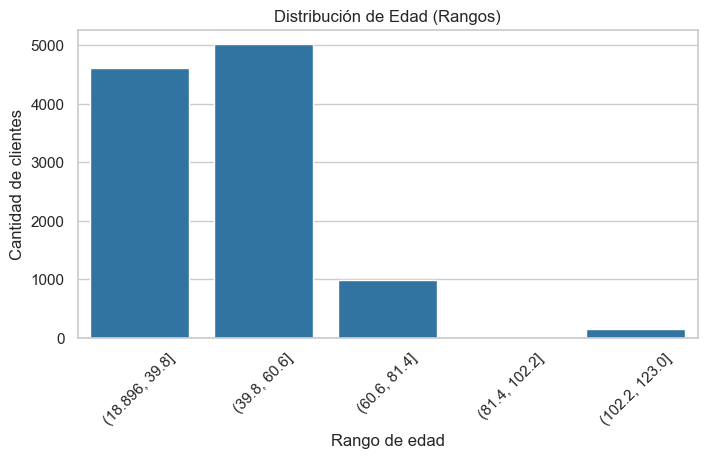

In [45]:
df_eda["edad_rango"] = pd.cut(df_eda["edad_cliente"], bins=5)

edad_counts = df_eda["edad_rango"].value_counts().sort_index()

plt.figure()
sns.barplot(x=edad_counts.index.astype(str), y=edad_counts.values, color="#1f77b4")
plt.xticks(rotation=45)
plt.title("Distribución de Edad (Rangos)")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de clientes")
plt.show()

La mayor concentración de clientes se encuentra en edades intermedias, lo cual es consistente con la población económicamente activa.

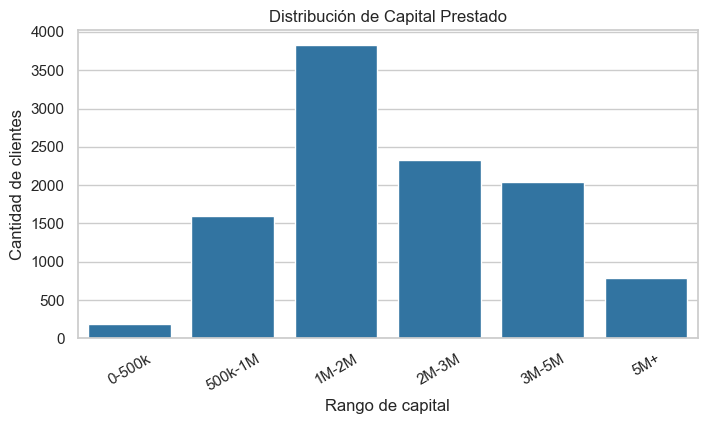

In [46]:
bins = [0, 500000, 1000000, 2000000, 3000000, 5000000, df_eda["capital_prestado"].max()]
labels = ["0-500k", "500k-1M", "1M-2M", "2M-3M", "3M-5M", "5M+"]

df_eda["capital_rango"] = pd.cut(
    df_eda["capital_prestado"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

capital_counts = df_eda["capital_rango"].value_counts().sort_index()

plt.figure()
sns.barplot(x=capital_counts.index, y=capital_counts.values, color="#1f77b4")
plt.title("Distribución de Capital Prestado")
plt.xlabel("Rango de capital")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=30)
plt.show()

La mayoría de los clientes se concentra en montos bajos e intermedios, mientras que los valores altos son menos frecuentes, evidenciando una distribución sesgada a la derecha.

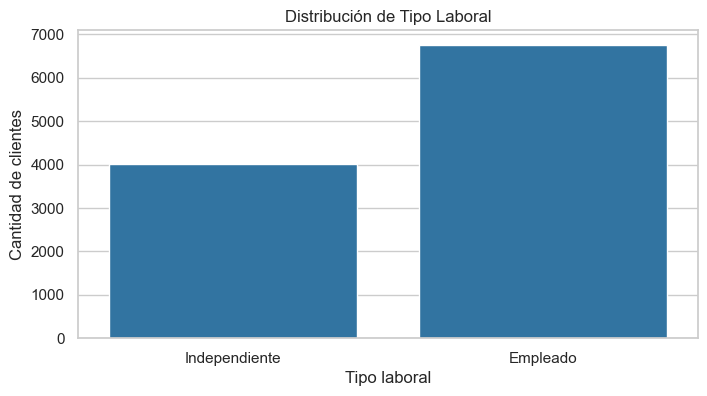

In [47]:
plt.figure()
sns.countplot(data=df_eda, x="tipo_laboral", color="#1f77b4")
plt.title("Distribución de Tipo Laboral")
plt.xlabel("Tipo laboral")
plt.ylabel("Cantidad de clientes")
plt.show()

Predominan los clientes empleados frente a independientes, lo cual puede influir en la estabilidad financiera.

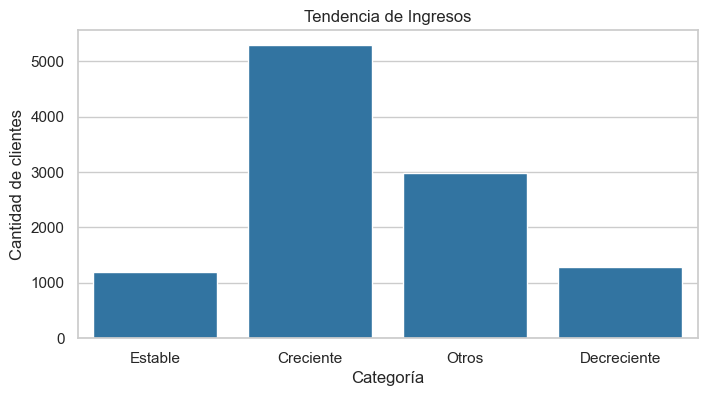

In [48]:
plt.figure()
sns.countplot(data=df_eda, x="tendencia_ingresos_limpia", color="#1f77b4")
plt.title("Tendencia de Ingresos")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de clientes")
plt.show()

Se observa una predominancia de ingresos crecientes, lo cual sugiere un contexto favorable para el cumplimiento de pagos.

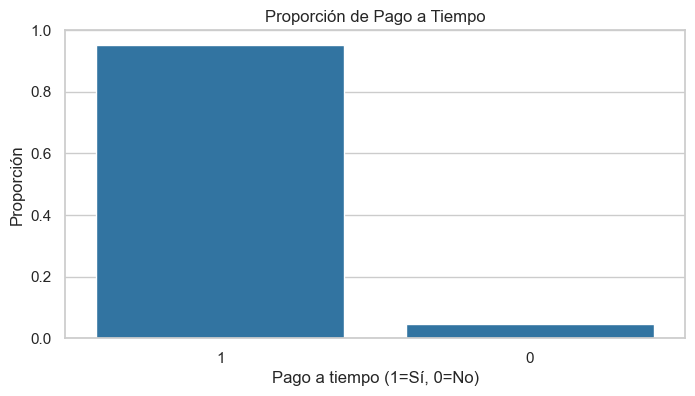

pago_atiempo
1    0.952523
0    0.047477
Name: proportion, dtype: float64

In [49]:
pago_counts = df_eda["pago_atiempo"].value_counts(normalize=True)

plt.figure()
sns.barplot(x=pago_counts.index.astype(str), y=pago_counts.values, color="#1f77b4")
plt.title("Proporción de Pago a Tiempo")
plt.xlabel("Pago a tiempo (1=Sí, 0=No)")
plt.ylabel("Proporción")
plt.show()

pago_counts

Existe una fuerte predominancia de clientes que cumplen con sus pagos, lo que indica un desbalance de clases que deberá ser considerado en el modelado.

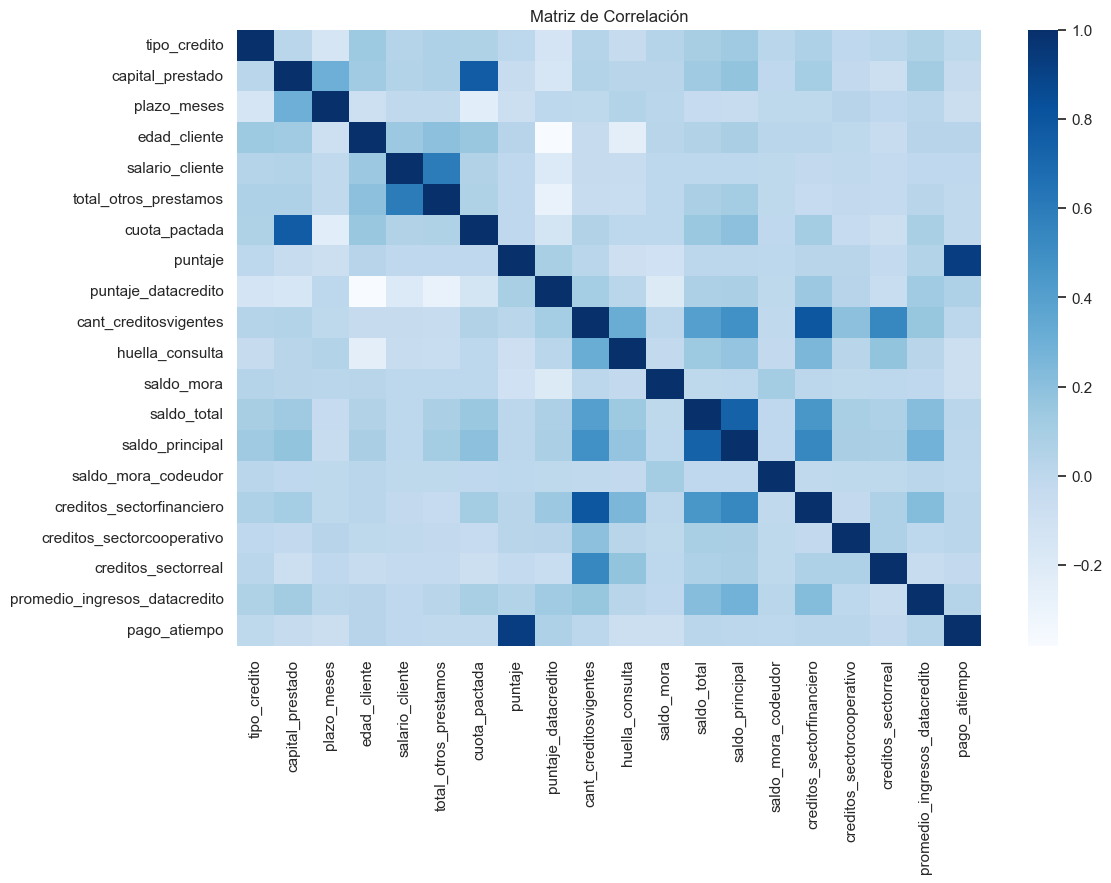

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(df_eda[num_cols].corr(), cmap="Blues")
plt.title("Matriz de Correlación")
plt.show()

La matriz de correlación permite identificar relaciones entre variables numéricas.

Se observan correlaciones esperadas entre variables financieras, sin evidencias de multicolinealidad severa. Esto es favorable para la construcción de modelos predictivos.

#### Conclusion 

El análisis exploratorio permitió identificar patrones relevantes en el comportamiento de los clientes, así como inconsistencias en variables categóricas que fueron corregidas mediante una limpieza exploratoria mínima.

Se observa un dataset con predominancia de clientes que cumplen con sus pagos, lo que indica un desbalance de clases a considerar en el modelado.

Asimismo, variables financieras y demográficas presentan distribuciones heterogéneas, lo que sugiere la necesidad de aplicar transformaciones y feature engineering en etapas posteriores.

Finalmente, el análisis de correlación no evidencia problemas severos de multicolinealidad, lo cual es favorable para la construcción de modelos robustos.

_______________________________________________________________________________________

## Análisis bivariable

En esta sección se analiza la relación entre distintas variables del dataset y la variable objetivo `pago_atiempo`.

El objetivo es identificar diferencias de comportamiento entre clientes que cumplen con sus pagos y aquellos que no, detectando variables que podrían aportar capacidad predictiva al modelo.

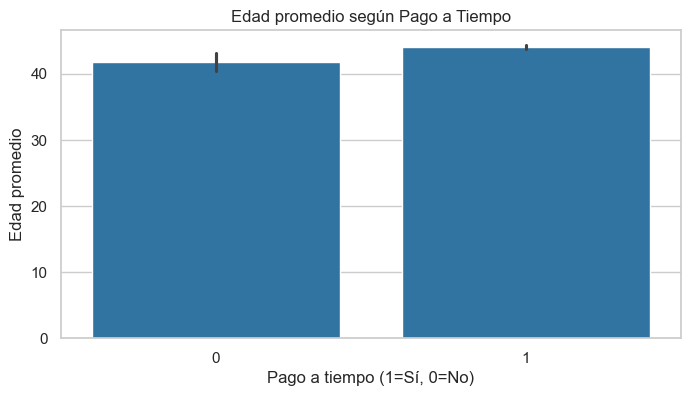

In [51]:
plt.figure()
sns.barplot(data=df_eda, x="pago_atiempo", y="edad_cliente", color="#1f77b4")
plt.title("Edad promedio según Pago a Tiempo")
plt.xlabel("Pago a tiempo (1=Sí, 0=No)")
plt.ylabel("Edad promedio")
plt.show()

La comparación de la edad promedio según el comportamiento de pago permite evaluar si existe una diferencia etaria entre clientes cumplidores e incumplidores.

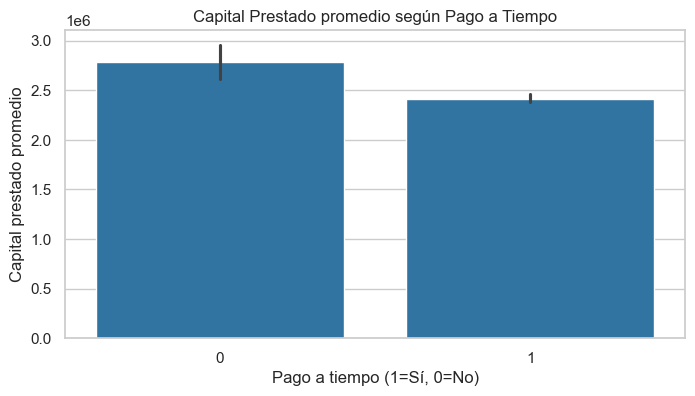

In [52]:
plt.figure()
sns.barplot(data=df_eda, x="pago_atiempo", y="capital_prestado", color="#1f77b4")
plt.title("Capital Prestado promedio según Pago a Tiempo")
plt.xlabel("Pago a tiempo (1=Sí, 0=No)")
plt.ylabel("Capital prestado promedio")
plt.show()

Este análisis permite observar si los clientes con mayores montos de capital prestado presentan diferencias en su comportamiento de pago.

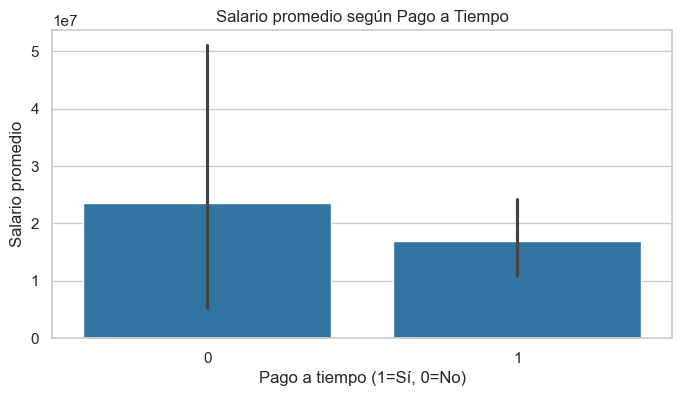

In [53]:
plt.figure()
sns.barplot(data=df_eda, x="pago_atiempo", y="salario_cliente", color="#1f77b4")
plt.title("Salario promedio según Pago a Tiempo")
plt.xlabel("Pago a tiempo (1=Sí, 0=No)")
plt.ylabel("Salario promedio")
plt.show()

El salario promedio permite identificar si existe relación entre capacidad de ingreso y cumplimiento de pago.

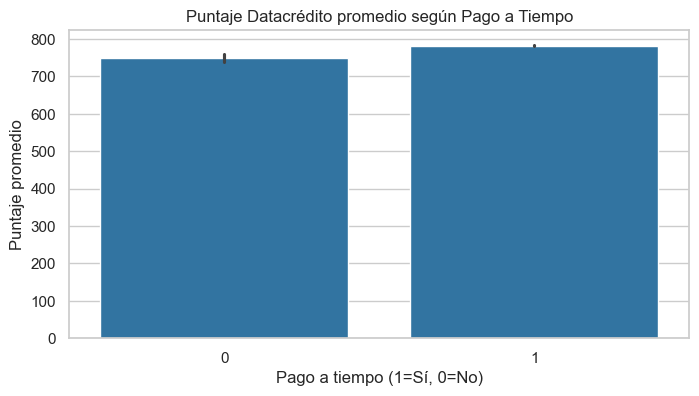

In [54]:
plt.figure()
sns.barplot(data=df_eda, x="pago_atiempo", y="puntaje_datacredito", color="#1f77b4")
plt.title("Puntaje Datacrédito promedio según Pago a Tiempo")
plt.xlabel("Pago a tiempo (1=Sí, 0=No)")
plt.ylabel("Puntaje promedio")
plt.show()

El puntaje de datacrédito es una variable de gran interés, ya que puede reflejar el nivel de riesgo crediticio del cliente y su relación con el pago oportuno.

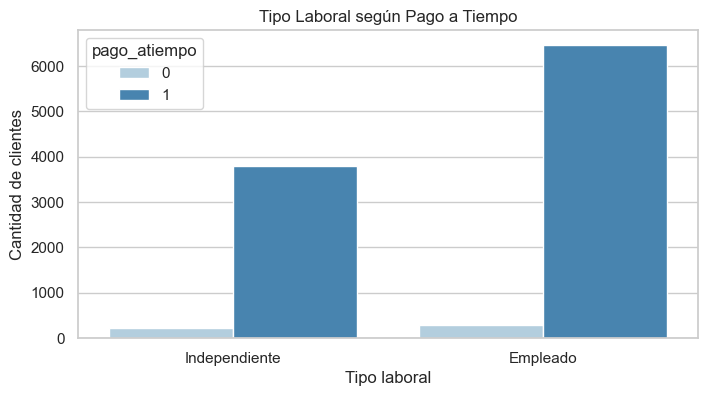

In [55]:
plt.figure()
sns.countplot(data=df_eda, x="tipo_laboral", hue="pago_atiempo", palette="Blues")
plt.title("Tipo Laboral según Pago a Tiempo")
plt.xlabel("Tipo laboral")
plt.ylabel("Cantidad de clientes")
plt.show()

La distribución del tipo laboral según el comportamiento de pago permite evaluar si la estabilidad laboral está asociada al cumplimiento financiero.

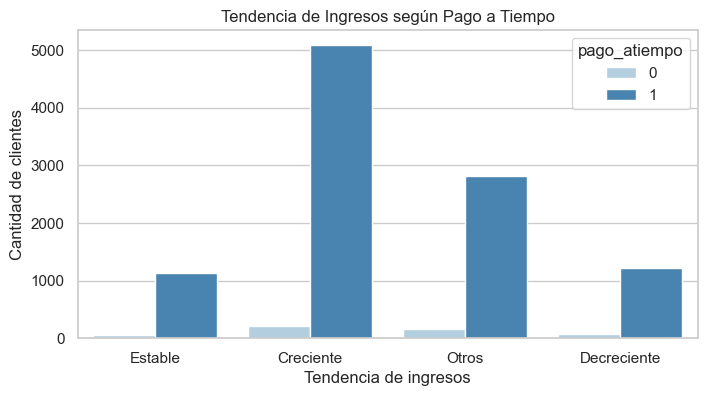

In [56]:
plt.figure()
sns.countplot(data=df_eda, x="tendencia_ingresos_limpia", hue="pago_atiempo", palette="Blues")
plt.title("Tendencia de Ingresos según Pago a Tiempo")
plt.xlabel("Tendencia de ingresos")
plt.ylabel("Cantidad de clientes")
plt.show()

Este gráfico permite analizar si la evolución de los ingresos del cliente se relaciona con una mayor o menor probabilidad de cumplir con sus pagos.

In [57]:
tabla_tipo_laboral = pd.crosstab(df_eda["tipo_laboral"], df_eda["pago_atiempo"], normalize="index") * 100
tabla_tipo_laboral

pago_atiempo,0,1
tipo_laboral,,
Empleado,4.293752,95.706248
Independiente,5.512597,94.487403


La tabla cruzada muestra la proporción de clientes cumplidores e incumplidores dentro de cada categoría laboral, facilitando una comparación más precisa.

In [58]:
tabla_tendencia = pd.crosstab(df_eda["tendencia_ingresos_limpia"], df_eda["pago_atiempo"], normalize="index") * 100
tabla_tendencia

pago_atiempo,0,1
tendencia_ingresos_limpia,,
Creciente,3.910087,96.089913
Decreciente,6.274206,93.725794
Estable,4.629630,95.370370
Otros,5.618729,94.381271


La tabla cruzada por tendencia de ingresos permite comparar el comportamiento de pago relativo dentro de cada grupo, más allá de la cantidad absoluta de clientes.

## Conclusión del análisis bivariable

El análisis bivariable permitió identificar diferencias relevantes entre los clientes que cumplen con sus pagos y aquellos que no.

Se observa que variables como salario, capital prestado y puntaje de datacrédito presentan comportamientos diferenciados según la variable objetivo. En particular, los clientes con menor salario y menor puntaje crediticio tienden a mostrar una mayor propensión al incumplimiento.

Asimismo, variables categóricas como tipo laboral y tendencia de ingresos también evidencian ciertas diferencias, donde perfiles con menor estabilidad o con ingresos decrecientes presentan un mayor riesgo financiero.

Se observa que, si bien los clientes con menor salario presentan mayor propensión al incumplimiento, la variable objetivo se encuentra desbalanceada, con predominancia de la clase de clientes cumplidores.

Este desbalance deberá ser considerado en la etapa de modelado, mediante técnicas como ajuste de pesos o métodos de remuestreo.

En conjunto, estos hallazgos sugieren que varias de las variables analizadas tienen potencial valor predictivo y serán relevantes en la construcción del modelo.

_________________________________________________________________________________________

## Análisis multivariable y preparación para modelado

En esta sección se analizan múltiples variables en conjunto, con el objetivo de identificar relaciones más complejas y evaluar qué variables podrían aportar mayor valor predictivo.

Además, se comienza a preparar el dataset para etapas posteriores de modelado, identificando variables relevantes y posibles transformaciones necesarias.

In [59]:
corr_target = df_eda[num_cols].corr()["pago_atiempo"].sort_values(ascending=False)
corr_target

pago_atiempo                     1.000000
puntaje                          0.923134
puntaje_datacredito              0.067882
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorfinanciero        0.021390
creditos_sectorcooperativo       0.021267
saldo_total                      0.014364
saldo_principal                  0.011473
cant_creditosvigentes            0.008829
saldo_mora_codeudor              0.002631
tipo_credito                     0.000951
salario_cliente                 -0.003981
total_otros_prestamos           -0.010041
cuota_pactada                   -0.011814
creditos_sectorreal             -0.023306
capital_prestado                -0.040624
plazo_meses                     -0.063105
saldo_mora                      -0.073458
huella_consulta                 -0.073737
Name: pago_atiempo, dtype: float64

El análisis de correlación con la variable objetivo permite identificar qué variables tienen mayor relación lineal con el comportamiento de pago.

Las variables con mayor correlación (positiva o negativa) pueden ser candidatas relevantes para el modelo predictivo.

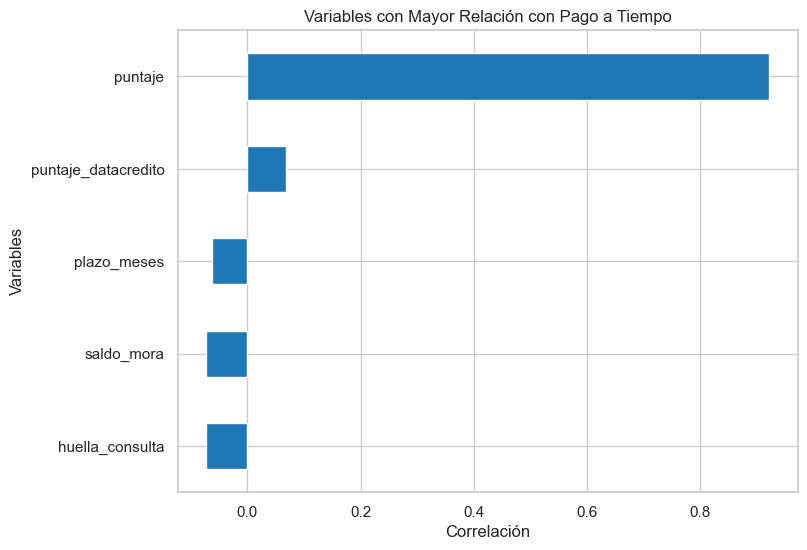

In [63]:
# Seleccionar solo correlaciones relevantes
corr_filtrado = corr_target.drop("pago_atiempo")

# Filtrar por magnitud (ej: > 0.05)
corr_filtrado = corr_filtrado[abs(corr_filtrado) > 0.05]

# Ordenar
corr_filtrado = corr_filtrado.sort_values()

plt.figure(figsize=(8,6))
corr_filtrado.plot(kind="barh", color="#1f77b4")
plt.title("Variables con Mayor Relación con Pago a Tiempo")
plt.xlabel("Correlación")
plt.ylabel("Variables")
plt.show()

Se observa que pocas variables presentan una relación significativa con la variable objetivo.

En particular, el puntaje crediticio destaca como la variable con mayor correlación, lo que sugiere un fuerte poder predictivo en el comportamiento de pago.

El resto de las variables presentan correlaciones bajas, lo cual no implica que no sean útiles, sino que su aporte puede ser no lineal o depender de interacciones con otras variables.

Asimismo, la alta correlación de una única variable sugiere la necesidad de evaluar posibles riesgos de dependencia excesiva del modelo en un solo predictor.

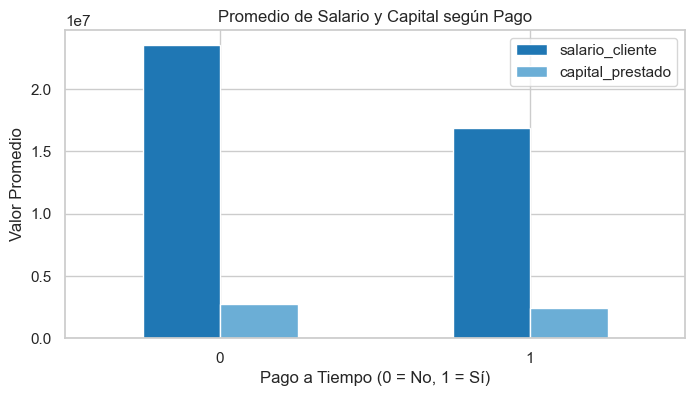

In [64]:
df_eda.groupby("pago_atiempo")[["salario_cliente", "capital_prestado"]].mean().plot(
    kind="bar",
    color=["#1f77b4", "#6baed6"]
)

plt.title("Promedio de Salario y Capital según Pago")
plt.xlabel("Pago a Tiempo (0 = No, 1 = Sí)")
plt.ylabel("Valor Promedio")
plt.xticks(rotation=0)
plt.show()

El análisis multivariable permite observar diferencias claras entre los grupos de clientes.

Se evidencia que los clientes que no cumplen con sus pagos tienden a presentar menores niveles de ingreso promedio, lo que refuerza la relación entre capacidad económica y riesgo de incumplimiento.

Asimismo, se observan diferencias en el capital prestado, lo cual sugiere que la combinación de variables financieras es relevante para explicar el comportamiento de pago.

In [65]:
features = [
    "edad_cliente",
    "capital_prestado",
    "salario_cliente",
    "puntaje_datacredito",
    "cant_creditosvigentes",
    "saldo_total",
    "saldo_mora"
]

X = df_eda[features]
y = df_eda["pago_atiempo"]

X.head()

,edad_cliente,capital_prestado,salario_cliente,puntaje_datacredito,cant_creditosvigentes,saldo_total,saldo_mora
0,42,3692160.0,8000000,695.0,10,51258.0,0.0
1,60,840000.0,3000000,789.0,3,8673.0,0.0
2,36,5974028.4,4036000,740.0,4,18702.0,0.0
3,48,1671240.0,1524547,837.0,4,15782.0,0.0
4,44,2781636.0,5000000,771.0,4,204804.0,0.0


Se selecciona un conjunto preliminar de variables numéricas con potencial valor predictivo, basado en los análisis previos.

Estas variables serán utilizadas como base para la construcción del modelo en etapas posteriores.

In [66]:
X.isnull().sum()

edad_cliente               0
capital_prestado           0
salario_cliente            0
puntaje_datacredito        6
cant_creditosvigentes      0
saldo_total              156
saldo_mora               156
dtype: int64

Se verifica la presencia de valores nulos en las variables seleccionadas, lo cual es un paso fundamental antes de entrenar modelos.

## Conclusión del análisis multivariable

El análisis multivariable permitió identificar relaciones más complejas entre variables, así como reforzar la relevancia de ciertas variables para la predicción del comportamiento de pago.

Se destaca la importancia de variables financieras y de perfil del cliente, como salario, capital prestado y puntaje crediticio.

Asimismo, se definió un conjunto preliminar de variables predictoras que serán utilizadas en la etapa de modelado.

Finalmente, se verificó la calidad de los datos en términos de valores faltantes, asegurando una base adecuada para el entrenamiento de modelos predictivos.